# -------- Armbruster2026_MapMyCellOutputAnalysis--------

Version: 2026-07-30

- In this script we analyzed the output of the MapMyCell algorithm (Allen Institute; RRID:SCR_024672) in which we forwarded the raw count matrix of our annotated zebrafish CA clusters with renamed gene names as their respective mouse orthologs created in "Armbruster2026_MapMyCellInputGeneration".

- This script also exported the unfiltered as well as filtered MapMyCell output data .csv files shown in Table S5C and S5D as well as created the plot shown in Figure 5A. 

- The session info including the used packages and their versions is provided at the end of this script.

# 1. Load packages

In [1]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import datetime
import hashlib
import json
import pandas as pd
import pathlib
import scipy.sparse
import subprocess
import tempfile
import umap
import session_info

# 2. Load data

In [2]:
csv_path = r"D:\scRNAseq\10X\DA136\SeuratAnalysis_2024-09-03\MapMyCells\MapMyCells_output_data\own-zebrafish-data_yao-mousebrain-data_HierarchicalMapping.csv"

- Inspect output file

In [3]:
zf_mapped_to_mouse_Yao2023 = pd.read_csv(csv_path, comment="#", index_col=0)
zf_mapped_to_mouse_Yao2023

,class_label,class_name,class_bootstrapping_probability,subclass_label,subclass_name,subclass_bootstrapping_probability,supertype_label,supertype_name,supertype_bootstrapping_probability,cluster_label,cluster_name,cluster_alias,cluster_bootstrapping_probability
cell_id,,,,,,,,,,,,,
AAACCCACACTCCGGA_Hyp3,CS20230722_CLAS_12,12 HY GABA,0.17,CS20230722_SUBC_107,107 DMH Hmx2 Gaba,0.41,CS20230722_SUPT_0489,0489 DMH Hmx2 Gaba_3,0.50,CS20230722_CLUS_1939,1939 DMH Hmx2 Gaba_3,1897,0.27
AAACCCATCTACTATC_Hb3,CS20230722_CLAS_24,24 MY Glut,0.76,CS20230722_SUBC_238,238 NTS Phox2b Glut,0.37,CS20230722_SUPT_0964,0964 NTS Phox2b Glut_6,0.59,CS20230722_CLUS_4283,4283 NTS Phox2b Glut_6,3957,0.26
AAACGAAAGGCTTCCG_PrT,CS20230722_CLAS_20,20 MB GABA,0.81,CS20230722_SUBC_202,202 PRT Tcf7l2 Gaba,0.33,CS20230722_SUPT_0829,0829 PRT Tcf7l2 Gaba_1,0.83,CS20230722_CLUS_3601,3601 PRT Tcf7l2 Gaba_1,3171,0.32
AAACGAACAAGTGCAG_pTub,CS20230722_CLAS_14,14 HY Glut,0.46,CS20230722_SUBC_134,134 PH-ant-LHA Otp Bsx Glut,0.56,CS20230722_SUPT_0591,0591 PH-ant-LHA Otp Bsx Glut_1,0.43,CS20230722_CLUS_2388,2388 PH-ant-LHA Otp Bsx Glut_1,2140,0.22
AAACGAAGTCTCGGGT_vFb.Prog2,CS20230722_CLAS_24,24 MY Glut,0.66,CS20230722_SUBC_238,238 NTS Phox2b Glut,0.39,CS20230722_SUPT_0964,0964 NTS Phox2b Glut_6,0.26,CS20230722_CLUS_4283,4283 NTS Phox2b Glut_6,3957,0.15
...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTGGTTTCTTCACAT_vFb.Prog1,CS20230722_CLAS_05,05 OB-IMN GABA,0.38,CS20230722_SUBC_045,045 OB-STR-CTX Inh IMN,0.45,CS20230722_SUPT_0170,0170 OB-STR-CTX Inh IMN_5,0.47,CS20230722_CLUS_0618,0618 OB-STR-CTX Inh IMN_5,1342,0.25
TTTGTTGCAACTAGAA_vFb.Prog2,CS20230722_CLAS_24,24 MY Glut,0.46,CS20230722_SUBC_238,238 NTS Phox2b Glut,0.66,CS20230722_SUPT_0965,0965 NTS Phox2b Glut_7,0.52,CS20230722_CLUS_4288,4288 NTS Phox2b Glut_7,3913,0.49
TTTGTTGCAAGGCGTA_vFb.Prog2,CS20230722_CLAS_12,12 HY GABA,0.47,CS20230722_SUBC_101,101 ZI Pax6 Gaba,0.89,CS20230722_SUPT_0462,0462 ZI Pax6 Gaba_4,0.48,CS20230722_CLUS_1743,1743 ZI Pax6 Gaba_4,1702,0.42


# 3. Inspect bootstrapping probabilities for different taxonomy tree levels

- Check for bootstrapping_probability: Hierarchical mapping assigns each cell 100 times, using a random subset of marker genes of the target taxonomy in each iteration, and assigns the cell to the type that is most correlated with it in the majority of the 100 iterations. 

- Distribution of bootstrapping_probability across the taxonomy tree:

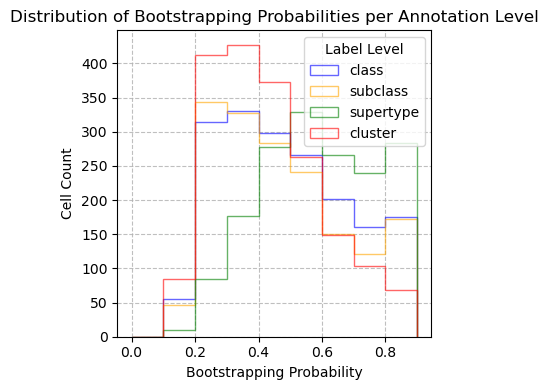

In [4]:
# Extract bootstrapping probabilities 
class_bootstrapping_probabilities = zf_mapped_to_mouse_Yao2023["class_bootstrapping_probability"].tolist()
subclass_bootstrapping_probabilities = zf_mapped_to_mouse_Yao2023["subclass_bootstrapping_probability"].tolist()
supertype_bootstrapping_probabilities = zf_mapped_to_mouse_Yao2023["supertype_bootstrapping_probability"].tolist()
cluster_bootstrapping_probabilities = zf_mapped_to_mouse_Yao2023["cluster_bootstrapping_probability"].tolist()

# Generate bootstrap_probabilities_df 
bootstrap_probabilities_df = pd.DataFrame({
    "class": class_bootstrapping_probabilities,
    "subclass": subclass_bootstrapping_probabilities,
    "supertype": supertype_bootstrapping_probabilities,
    "cluster": cluster_bootstrapping_probabilities
})

# Generae histogram
plt.figure(figsize=(4, 4))
bins = np.arange(0.0,1.0,0.1)

plt.hist(bootstrap_probabilities_df["class"], bins=bins, alpha=0.6, label="class", color="blue", histtype="step")
plt.hist(bootstrap_probabilities_df["subclass"], bins=bins, alpha=0.6, label="subclass", color="orange", histtype="step")
plt.hist(bootstrap_probabilities_df["supertype"], bins=bins, alpha=0.6, label="supertype", color="green", histtype="step")
plt.hist(bootstrap_probabilities_df["cluster"], bins=bins, alpha=0.6, label="cluster", color="red", histtype="step")

plt.xlabel("Bootstrapping Probability")
plt.ylabel("Cell Count")
plt.title("Distribution of Bootstrapping Probabilities per Annotation Level")
plt.legend(title="Label Level")
plt.grid(True, linestyle="--", alpha=0.8)
plt.tight_layout()

plt.savefig("bootstrap_probabilities.svg")
plt.show()



- We will use the subclass label for further analysis as it provides sufficient anatomical resolution.

# 4. Inspect assignments

- We will filter for cells which were assigned with a bootstrapping probability >= 0.5

In [5]:
label_level = "subclass"
cell_label_names = list(zf_mapped_to_mouse_Yao2023.index)
label_names = list()
for entry in cell_label_names:
    entry = entry.split("_",1)[1]
    label_names.append(entry)


zf_mapped_to_mouse_Yao2023["zf_annotation"] = label_names

zf_mapped_to_mouse_Yao2023_short = zf_mapped_to_mouse_Yao2023[[f"{label_level}_name", f"{label_level}_label", f"{label_level}_bootstrapping_probability", "zf_annotation"]]

# Save unfiltered subclass assignment table
zf_mapped_to_mouse_Yao2023_short.to_csv(r"D:\scRNAseq\10X\DA136\SeuratAnalysis_2024-09-03\MapMyCells\MapMyCells_output_data\mapmycells_unfiltered_results_table.csv")

# Filter for cells with bootstrap probability >= 0.5
zf_mapped_to_mouse_Yao2023_short = zf_mapped_to_mouse_Yao2023_short[zf_mapped_to_mouse_Yao2023_short[f"{label_level}_bootstrapping_probability"] >= 0.5]

- We will only visualize subclasses which were assigned to at least 15 cells. 

In [6]:
mapping_table = pd.crosstab(zf_mapped_to_mouse_Yao2023_short[f"{label_level}_name"], zf_mapped_to_mouse_Yao2023_short["zf_annotation"])

print("--------------------Unfiltered-----------------------")
print(mapping_table)

# Filter for cells with bootstrap probability >= 0.5
threshold = 15
filtered_mapping_table = mapping_table[mapping_table.sum(axis=1) >= threshold]
print("--------------------Filtered-----------------------")
print(filtered_mapping_table)




--------------------Unfiltered-----------------------
zf_annotation             Cb  DMX  Hb1  Hb2  Hb3  Hyp1  Hyp2  Hyp3  OB  PrT  \
subclass_name                                                                 
035 OB Eomes Ms4a15 Glut   0    0    0    0    0     0     0     0   0    0   
036 HPF CR Glut            0    0    0    0    0     0     0     0   0    0   
037 DG Glut                0    0    0    0    0     0     0     0   0    0   
038 DG-PIR Ex IMN          5    0    0    0    0     2     2     3   0    0   
039 OB Meis2 Thsd7b Gaba   0    0    0    0    0     0     0     2   1    0   
...                       ..  ...  ...  ...  ...   ...   ...   ...  ..  ...   
322 Tanycyte NN            0    0    0    0    0     0     1     1   0    0   
325 CHOR NN                0    0    0    0    0     0     0     0   0    0   
326 OPC NN                 1    0    0    0    0     1     0     5   0    0   
327 Oligo NN               1    0    0    0    1     1     0     3   0    1  

In [7]:
relevant_mouse_labels = filtered_mapping_table.index.tolist()
relevant_mouse_labels

['038 DG-PIR Ex IMN',
 '044 OB Dopa-Gaba',
 '045 OB-STR-CTX Inh IMN',
 '101 ZI Pax6 Gaba',
 '134 PH-ant-LHA Otp Bsx Glut',
 '202 PRT Tcf7l2 Gaba',
 '237 PRP-NI-PRNc-GRN Otp Glut',
 '238 NTS Phox2b Glut',
 '251 NTS Dbh Glut',
 '252 DMX VII Tbx20 Chol']

In [8]:
# Save table filtered for bootstrap value >0.5 and for mouse subclasses to which >= 15 query cells were assigned
zf_mapped_to_mouse_Yao2023_short = zf_mapped_to_mouse_Yao2023_short[zf_mapped_to_mouse_Yao2023_short.subclass_name.isin(relevant_mouse_labels)]
zf_mapped_to_mouse_Yao2023_short.to_csv(r"D:\scRNAseq\10X\DA136\SeuratAnalysis_2024-09-03\MapMyCells\MapMyCells_output_data\mapmycells_bootstrap_subclass_filtered_results_table.csv")



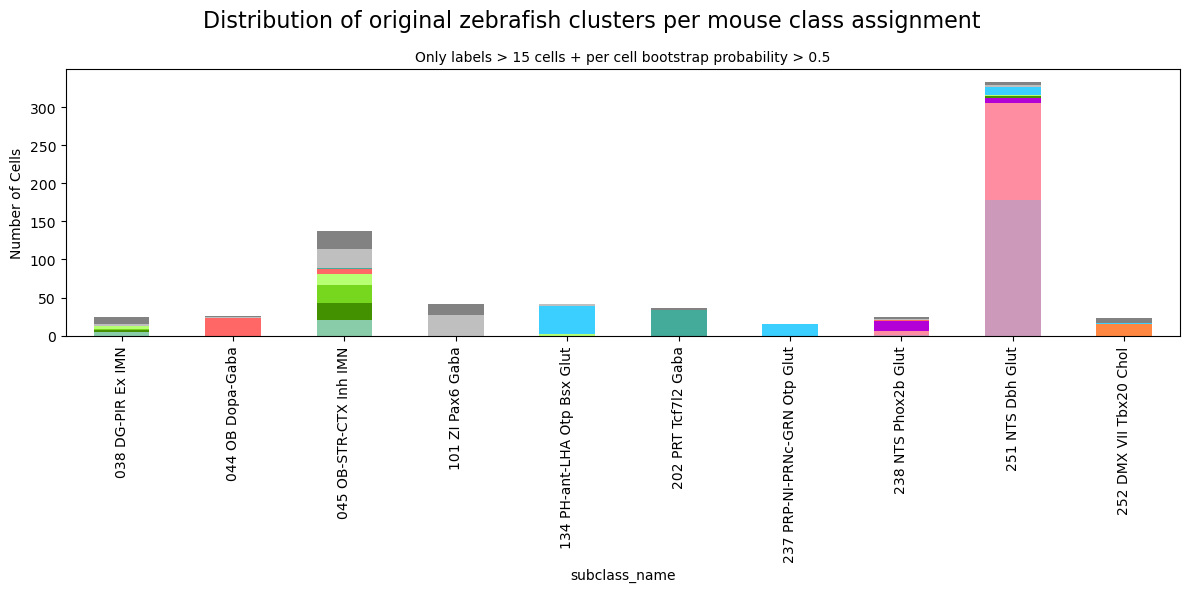

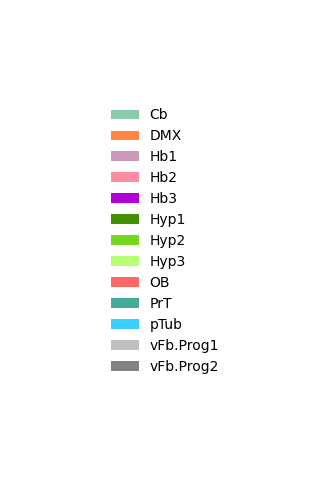

In [9]:
# Paths for saving
figpath = r"D:\scRNAseq\10X\DA136\SeuratAnalysis_2024-09-03\Figures\Figure5_MausComparison\mapmycell_label_distribution_figure.svg"
legendpath = r"D:\scRNAseq\10X\DA136\SeuratAnalysis_2024-09-03\Figures\Figure5_MausComparison\mapmycell_label_distribution_legend.svg"

my_colors = [
 "#88CCAA", 
 "#ff8742", 
 "#CC99BB",
 "#FF8DA1",
 "#B300D6", 
 "#449100",
 "#77D61E",
 "#B7FF73",
 "#FF6666",
 "#44AA99",
 "#3BCFFF",
 "#BFBFBF",
 "#828282"
]




# Create and save plot w/o legend
plot_figure = filtered_mapping_table.plot(kind="bar", stacked=True, figsize=(12, 6), color=my_colors, legend=False)
plt.ylabel("Number of Cells")
plt.suptitle("Distribution of original zebrafish clusters per mouse class assignment ", fontsize = 16)
plt.title("Only labels > 15 cells + per cell bootstrap probability > 0.5", fontsize = 10)
plt.tight_layout()
plt.savefig(figpath)
plt.show()

# Create and save legend
plot_legend = plt.figure(figsize=(4, 6))
handles, labels = plot_figure.get_legend_handles_labels()
plot_legend.legend(handles, labels, loc='center', frameon=False)
plt.axis('off')  # Hide axes

# Save the legend
plt.savefig(legendpath)
plt.show()

# 5. Session info

In [ ]:
session_info.show()